<font size=6><b>Lec07.딥러닝 RNN - 시계열

# <font color=red><b>시계열 데이터
* https://otexts.com/fppkr/
* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 데이터(Non-Stationary)</b></font>
    - 시간에 따라 평균, 분산이 변화
    - 예측이 어렵고 통계 분석이 제한되므로 분석 전에 정상화 처리 필수
* <font color=red><b>비정상성 --> 정상성</b></font>
    - 평균 : 이동평균(MA:Moving Average), 차분(Difference)
    - 분산 : 스케일링(MinMax), 로그변환(양수인경우)

# <font color=red><b>시계열 데이터의 특징

* <font color=red><b>추세(trend)</b></font>
    - 증가 감소 패턴
    - 물가상승
* <font color=red><b>계절성(seasonality)</b></font>
    - 짧은(주, 요일, 월) 빈도로 보이는 패턴(대체로 일정)
    - 블랙프라이데이 매출, 여름철우산판매량
* <font color=red><b>주기성(cycle)</b></font>
    - 장기적(고정 빈도가 없다)으로 증가/감소 패턴
    - 경기 순환(business cycle)
* <font color=red><b>백색잡음(white noise == epsilon)</b></font>
    - 균일한 크기의 무작위적 잡음

# <b>시계열 분석 데이터셋 topN

| 난이도   | Dataset                   | 설명                  | 특징                                | 데이터 크기        | Kaggle URL                                                                                                                                               |
| ----- | ------------------------- | ------------------- | --------------------------------- | ------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| *     | Shampoo Sales             | 월별 샴푸 판매량 (초소형 시계열) | RNN기초학습 | 36 rows       | [https://www.kaggle.com/datasets/jbrownlee/shampoo-sales](https://www.kaggle.com/datasets/jbrownlee/shampoo-sales)                                       |
| *     | <b>Airline Passengers</b>        | 월별 국제 항공 승객 수       | 주기,계절성(Trend,seasonality)학습       | 144 rows      | [https://www.kaggle.com/datasets/rakannimer/air-passengers](https://www.kaggle.com/datasets/rakannimer/air-passengers)                                   |
| **    | <b>--Daily Minimum Temperature</b> | 멜버른 일별 최소 기온        | 계절성(seasonality) 학습               | 3,650 rows    | [https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me](https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me) |
| **    | Sunspots                  | 태양 흑점 수             | 주기(periodicity) 데이터           | ~2,820 rows   | [https://www.kaggle.com/datasets/rohanrao/sunspots](https://www.kaggle.com/datasets/rohanrao/sunspots)                                                   |
| ***   | Electricity Consumption   | 전력 사용량 시계열          | 대규모 다변량 시계열                       | 200,000+ rows | [https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)             |
| ***   | Traffic Volume            | 교통량 데이터             |  다변량(날씨,시간,교통량)        | ~48,000 rows  | [https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume](https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume)           |
| ****  | <b>Bitcoin Price</b>             | 암호화폐 가격             | 고변동 금융 시계열                        | ~5,000+ rows  | [https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data)               |
| ****  | Stock Market              | 주가 시계열              | 다종목 금융 데이터                        | ~20,000+ rows | [https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)                     |
| ***** | M5 Forecasting            | 대형 시계열 예측           | 세계 최대 리테일 시계열 대회                  | 30M+ rows     | [https://www.kaggle.com/competitions/m5-forecasting-accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy)                               |
| ***** | <b>Store Sales Forecasting</b>   | 매출 예측               | 다변량 매출                         | ~125k rows    | [https://www.kaggle.com/competitions/store-sales-time-series-forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)       |


# <b>Air Passengers

*  https://www.kaggle.com/datasets/rakannimer/air-passengers
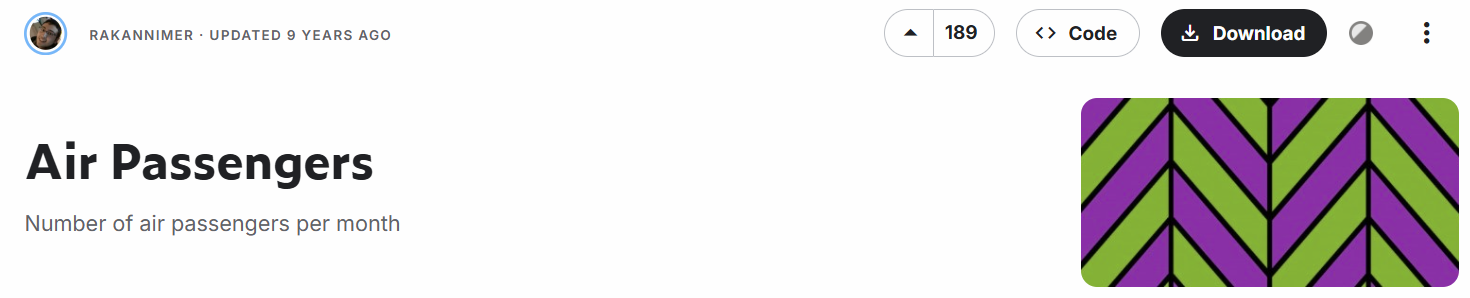

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
df = pd.read_csv("./dataset/AirPassengers.csv")
df.head(2)

,Month,#Passengers
0,1949-01,112
1,1949-02,118


In [3]:
df = pd.read_csv("./dataset/AirPassengers.csv", parse_dates=["Month"])
df.columns = ["rdate", "cnt"]
#df["rdate"] = df["rdate"].dt.strftime("%Y-%m")
#df["rdate"] = pd.to_datetime(df["rdate"], format="%Y-%m")
pd.to_datetime(df["rdate"])
df.head(2)

,rdate,cnt
0,1949-01-01,112
1,1949-02-01,118


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   rdate   144 non-null    datetime64[ns]
 1   cnt     144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


# <b>EDA

In [5]:
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01-01,112
1949-02-01,118


In [6]:
df.index.min(), df.index.max()

(Timestamp('1949-01-01 00:00:00'), Timestamp('1960-12-01 00:00:00'))

<Figure size 640x480 with 0 Axes>

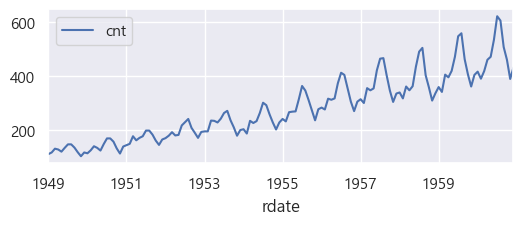

In [7]:
plt.figure()
df.plot(figsize=(6,2))
plt.show()

# <b>전처리 & 가공

* 정상성 데이터(Stationary)
    * 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    * 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 --> 정상성
    - 평균 : 차분(Difference)
    - 분산 : 이동평균(MA:Moving Average), 로그변환(양수인경우), 스케일링(MinMax)

## 차분(Difference)

In [8]:
df['diff1'] = df['cnt'].diff(1)
df['diff1'] = df['diff1'].bfill()
df.head()

,cnt,diff1
rdate,,
1949-01-01,112,6.0
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0


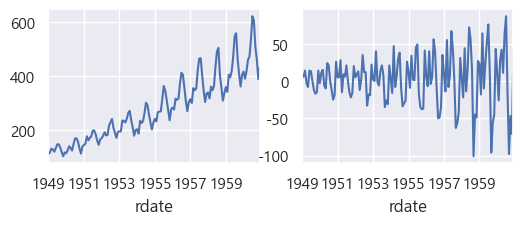

In [9]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(6,2))

plt.show()

## 이동평균(MA)
* 5(w), 20(m), 60(q), 120(2q:상반기/하반기), 200(y)

In [10]:
df['ma5']  = df['cnt'].rolling(5).mean()
df['ma20'] = df['cnt'].rolling(20).mean()
df.head(5)

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,NaN,NaN
1949-02-01,118,6.0,NaN,NaN
1949-03-01,132,14.0,NaN,NaN
1949-04-01,129,-3.0,NaN,NaN
1949-05-01,121,-8.0,122.4,NaN


### 결측채우기 : 앞/뒤 값으로 채우기
<pre><font color=red><b>df['컬럼'] = df['컬럼'].ffill() : 앞값으로 채우기
df['컬럼'] = df['컬럼'].bfill() : 뒤값으로 채우기

inplace=True XXXXXXXXXXXXXXXXXXXXXXXXXX 

In [11]:
df['ma5']  = df['ma5'].bfill()
df['ma20'] = df['ma20'].bfill()
df.head(6)

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,122.4,132.55
1949-02-01,118,6.0,122.4,132.55
1949-03-01,132,14.0,122.4,132.55
1949-04-01,129,-3.0,122.4,132.55
1949-05-01,121,-8.0,122.4,132.55
1949-06-01,135,14.0,127.0,132.55


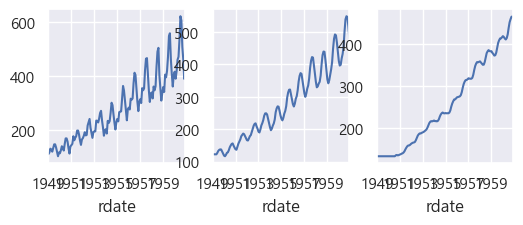

In [12]:
plt.figure()

plt.subplot(1,3,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,3,2)
df['ma5'].plot(figsize=(6,2))

plt.subplot(1,3,3)
df['ma20'].plot(figsize=(6,2))

plt.show()

## 로그변환(양수인경우)

In [13]:
df['log'] = np.log1p(df['cnt'])
df.head()

,cnt,diff1,ma5,ma20,log
rdate,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388
1949-02-01,118,6.0,122.4,132.55,4.779123
1949-03-01,132,14.0,122.4,132.55,4.890349
1949-04-01,129,-3.0,122.4,132.55,4.867534
1949-05-01,121,-8.0,122.4,132.55,4.804021


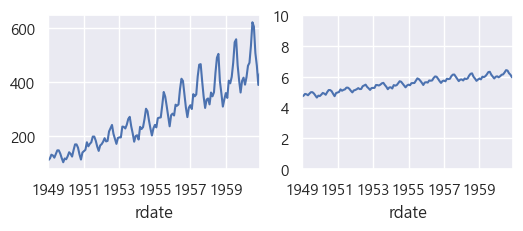

In [14]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['log'].plot(figsize=(6,2))
plt.ylim(0,10)

plt.show()

## 스케일링(MinMax)

In [15]:
df['cnt'].values.reshape(-1,1)[:3]

array([[112],
       [118],
       [132]])

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
res = scaler.fit_transform(df['cnt'].values.reshape(-1,1))  #------2D
res[:3]

array([[0.01544402],
       [0.02702703],
       [0.05405405]])

In [17]:
df['scale'] = res.reshape(-1)
df.head(2)

,cnt,diff1,ma5,ma20,log,scale
rdate,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027


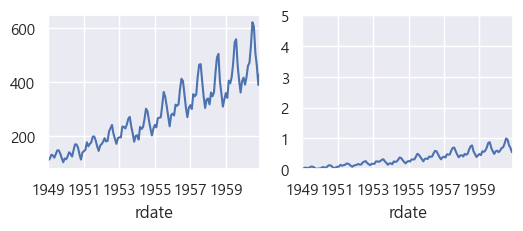

In [18]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['scale'].plot(figsize=(6,2))
plt.ylim(0,5)

plt.show()

## 정상성 데이터
* 평균(diff) , 분산(log)

In [19]:
df['stat'] = np.log1p(df['cnt'])
df['stat'] = df['stat'].diff(1)
df['stat'] = df['stat'].bfill()
df.head(2)

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736


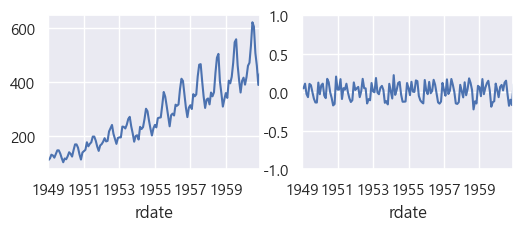

In [20]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['stat'].plot(figsize=(6,2))
plt.ylim(-1,1)

plt.show()

In [21]:
import numpy as np
arr = np.arange(11)

In [22]:
arr

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [23]:
window_size = 6
x = []
y = []
for i in range(len(arr) - window_size):
    x.append(arr[i:i+window_size])
    y.append(arr[i+window_size])
print(np.array(x))
print(np.array(y))

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


In [24]:
window_size = 6
x = []
y = []
for i in range(len(arr) - window_size):
    x.append(arr[i:i+window_size])
    y.append(arr[i+window_size])
print(np.array(x))
print(np.array(y))

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


In [25]:
import pandas as pd
df = pd.DataFrame(arr)

In [26]:
df

,0
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [27]:
arr2 = df.to_numpy()
arr2

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [28]:
window_size = 6
x = []
y = []
for i in range(len(arr2) - window_size):
    x.append(arr2[i:i+window_size])
    y.append(arr2[i+window_size])
print(np.array(x))
print(np.array(y))

[[[0]
  [1]
  [2]
  [3]
  [4]
  [5]]

 [[1]
  [2]
  [3]
  [4]
  [5]
  [6]]

 [[2]
  [3]
  [4]
  [5]
  [6]
  [7]]

 [[3]
  [4]
  [5]
  [6]
  [7]
  [8]]

 [[4]
  [5]
  [6]
  [7]
  [8]
  [9]]]
[[ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [29]:
np.array(x).shape, np.array(y).shape

((5, 6, 1), (5, 1))